Correlation coefficient (r) = -0.229
P-value = 0.00003


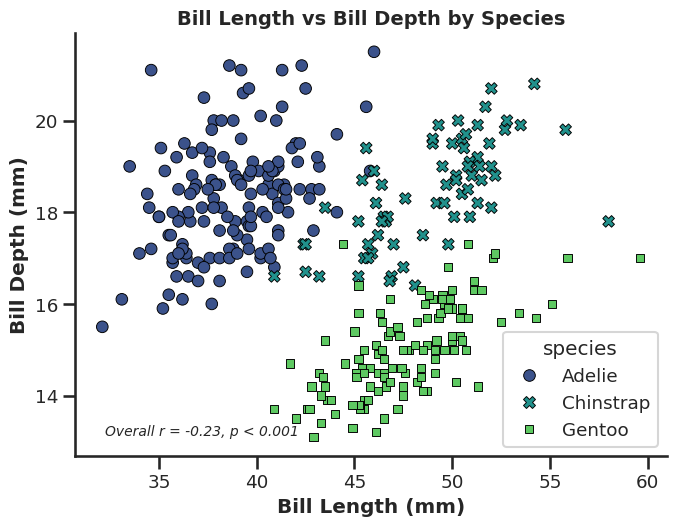

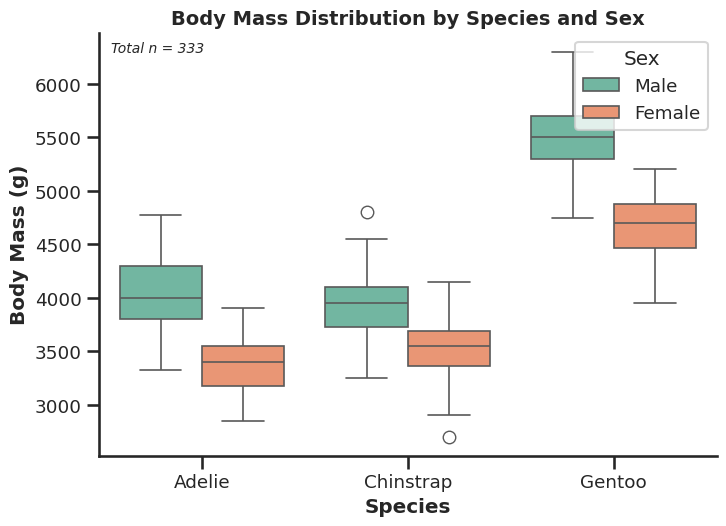

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset and remove missing values
penguins = sns.load_dataset("penguins").dropna()

from scipy import stats

corr, p_val = stats.pearsonr(penguins["bill_length_mm"], penguins["bill_depth_mm"])
print(f"Correlation coefficient (r) = {corr:.3f}")
print(f"P-value = {p_val:.5f}")

# Set publication-style aesthetics
sns.set_style("ticks")
sns.set_context("talk", font_scale=0.8)
palette = "viridis"

# ================================================================
# Plot 1: Scatter plot - Bill Length vs Bill Depth by Species
# (demonstrates species-level clustering / separability)
# ================================================================
plt.figure(figsize=(7, 5.5))
ax = sns.scatterplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    hue="species", style="species", palette=palette, s=70, edgecolor="black"
)

# Compute correlation coefficient for annotation
corr, p_val = stats.pearsonr(penguins["bill_length_mm"], penguins["bill_depth_mm"])
plt.title("Bill Length vs Bill Depth by Species", fontsize=14, fontweight="bold")
plt.xlabel("Bill Length (mm)", fontweight="bold")
plt.ylabel("Bill Depth (mm)", fontweight="bold")
plt.text(
    0.05, 0.05, f"Overall r = {corr:.2f}, p < 0.001" if p_val < 0.001 else f"r = {corr:.2f}, p = {p_val:.3f}",
    transform=ax.transAxes, fontsize=10, style="italic"
)
sns.despine()
plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# Plot 2: Boxplot - Body Mass by Species and Sex
# (demonstrates sexual dimorphism across species)
# ================================================================
plt.figure(figsize=(7.5, 5.5))
ax2 = sns.boxplot(
    data=penguins, x="species", y="body_mass_g", hue="sex",
    palette="Set2", linewidth=1.2
)
plt.title("Body Mass Distribution by Species and Sex", fontsize=14, fontweight="bold")
plt.xlabel("Species", fontweight="bold")
plt.ylabel("Body Mass (g)", fontweight="bold")

# Annotate sample size per group
counts = penguins.groupby(["species", "sex"]).size()
plt.text(
    0.02, 0.98, f"Total n = {len(penguins)}",
    transform=ax2.transAxes, fontsize=10, va="top", style="italic"
)
sns.despine()
plt.legend(title="Sex", loc="upper right")
plt.tight_layout()
plt.savefig("boxplot.png", dpi=300, bbox_inches="tight")
plt.show()